In [23]:
# Install dependencies in Google Colab
!pip install qiskit qiskit-aer matplotlib numpy

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

simulator = AerSimulator()

In [25]:
def make_simon_oracle(b: str) -> QuantumCircuit:
    n = len(b)
    qc = QuantumCircuit(2 * n, name="SimonOracle")

    # 1. Copy register 1 to register 2: |x>|0> -> |x>|x>
    for i in range(n):
        qc.cx(i, n + i)

    # 2. Map x and x ^ b to identical values in register 2
    if '1' in b:
        # Least significant bit where b has a 1 (Qiskit qubit ordering: index 0 is rightmost bit)
        b_rev = b[::-1]
        k = b_rev.index('1')
        for j in range(n):
            if b_rev[j] == '1':
                qc.cx(k, n + j)
    return qc

# Verify with truth table for '110'
b_easy = '110'
n = len(b_easy)
oracle_easy = make_simon_oracle(b_easy)

print(f"--- Truth Table Verification for Secret String s = '{b_easy}' ---")
print(f"{'Input x':<10} | {'Output f(x)':<12} | {'Input x ^ s':<12} | {'Output f(x ^ s)':<15} | {'Collision Match?'}")
print("-" * 70)

b_int = int(b_easy, 2)
for x in range(2**n):
    # Prepare |x>|0>
    init_circuit = QuantumCircuit(2 * n)
    x_str = format(x, f'0{n}b')
    for bit_idx, bit in enumerate(x_str[::-1]):
        if bit == '1':
            init_circuit.x(bit_idx)

    # Apply oracle
    test_qc = init_circuit.compose(oracle_easy)
    sv = Statevector.from_instruction(test_qc)
    # Extract measured base state
    out_state = list(sv.to_dict().keys())[0]
    fx = out_state[:n] # Most significant qubits represent the second register

    # Evaluate x ^ b
    x_pair = x ^ b_int
    x_pair_str = format(x_pair, f'0{n}b')
    init_pair = QuantumCircuit(2 * n)
    for bit_idx, bit in enumerate(x_pair_str[::-1]):
        if bit == '1':
            init_pair.x(bit_idx)
    test_pair_qc = init_pair.compose(oracle_easy)
    sv_pair = Statevector.from_instruction(test_pair_qc)
    fx_pair = list(sv_pair.to_dict().keys())[0][:n]

    print(f"{x_str:<10} | {fx:<12} | {x_pair_str:<12} | {fx_pair:<15} | {fx == fx_pair}")

--- Truth Table Verification for Secret String s = '110' ---
Input x    | Output f(x)  | Input x ^ s  | Output f(x ^ s) | Collision Match?
----------------------------------------------------------------------
000        | 000          | 110          | 000             | True
001        | 001          | 111          | 001             | True
010        | 100          | 100          | 100             | True
011        | 101          | 101          | 101             | True
100        | 100          | 010          | 100             | True
101        | 101          | 011          | 101             | True
110        | 000          | 000          | 000             | True
111        | 001          | 001          | 001             | True


In [26]:
def build_simon_circuit(b: str) -> QuantumCircuit:
    n = len(b)
    qc = QuantumCircuit(2 * n, n)

    # Superposition
    qc.h(range(n))
    qc.barrier()

    # Simon Oracle
    qc.append(make_simon_oracle(b), range(2 * n))
    qc.barrier()

    # Interference
    qc.h(range(n))
    qc.barrier()

    # Measurement on input register
    qc.measure(range(n), range(n))
    return qc

b_med = '110'
n_med = len(b_med)
circuit_med = build_simon_circuit(b_med)
t_qc = transpile(circuit_med, simulator)
counts = simulator.run(t_qc, shots=1024).result().get_counts()

print(f"--- Measured Outcomes (z where z · {b_med} = 0 mod 2) ---")
print("Raw Counts:", counts)

# Extract linearly independent vectors over GF(2)
def gf2_rank(matrix):
    mat = matrix.copy()
    rank = 0
    rows, cols = mat.shape
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if mat[r, col] == 1:
                pivot = r
                break
        if pivot is not None:
            mat[[rank, pivot]] = mat[[pivot, rank]]
            for r in range(rows):
                if r != rank and mat[r, col] == 1:
                    mat[r] = (mat[r] + mat[rank]) % 2
            rank += 1
    return rank

measured_vectors = []
for bitstring in counts.keys():
    # Convert bitstring to array of ints
    v = np.array([int(c) for c in bitstring], dtype=int)
    test_set = measured_vectors + [v]
    if gf2_rank(np.array(test_set)) > len(measured_vectors):
        measured_vectors.append(v)
    if len(measured_vectors) == n_med - 1:
        break

print(f"\nCollected {len(measured_vectors)} independent vectors for n={n_med}:")
for i, vec in enumerate(measured_vectors):
    print(f"Equation {i+1}: {' · '.join(map(str, vec))} · s = 0 (mod 2)")

--- Measured Outcomes (z where z · 110 = 0 mod 2) ---
Raw Counts: {'001': 253, '000': 269, '110': 257, '111': 245}

Collected 2 independent vectors for n=3:
Equation 1: 0 · 0 · 1 · s = 0 (mod 2)
Equation 2: 1 · 1 · 0 · s = 0 (mod 2)


In [27]:
def solve_simon_gf2(equations, n):
    """
    Finds the non-zero vector s such that M * s = 0 (mod 2).
    equations: list of vectors of length n
    """
    # Systematic search over all non-zero 2^n - 1 candidates
    # (or null space via Gauss-Jordan elimination)
    M = np.array(equations, dtype=int)
    candidates = []
    for candidate_int in range(1, 2**n):
        s_candidate = np.array([int(c) for c in format(candidate_int, f'0{n}b')], dtype=int)
        if np.all(np.dot(M, s_candidate) % 2 == 0):
            candidates.append(format(candidate_int, f'0{n}b'))
    return candidates

b_hard = '1101'
n_hard = len(b_hard)
circuit_hard = build_simon_circuit(b_hard)
t_qc_hard = transpile(circuit_hard, simulator)
counts_hard = simulator.run(t_qc_hard, shots=2048).result().get_counts()

# Collect equations
M_eqs = []
for bitstring in counts_hard.keys():
    v = np.array([int(c) for c in bitstring], dtype=int)
    test_set = M_eqs + [v]
    if gf2_rank(np.array(test_set)) > len(M_eqs):
        M_eqs.append(v)
    if len(M_eqs) == n_hard - 1:
        break

recovered = solve_simon_gf2(M_eqs, n_hard)
print(f"True Secret String:       {b_hard}")
print(f"Identified Equations (M):\n{np.array(M_eqs)}")
print(f"Solved Hidden String(s):  {recovered}")

True Secret String:       1101
Identified Equations (M):
[[1 1 1 0]
 [0 1 0 1]
 [1 1 0 0]]
Solved Hidden String(s):  ['1101']


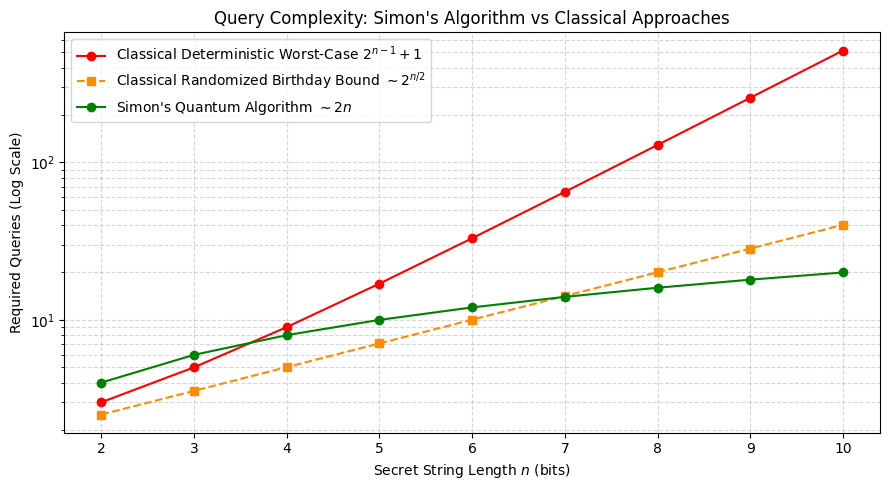

In [28]:
bit_lengths = list(range(2, 11))
simon_queries = [2 * n for n in bit_lengths] # O(n) queries
classical_worst_case = [2**(n - 1) + 1 for n in bit_lengths] # O(2^(n-1))
classical_expected_birthday = [np.sqrt(np.pi * 2**(n - 1)) for n in bit_lengths] # O(2^(n/2))

plt.figure(figsize=(9, 5))
plt.plot(bit_lengths, classical_worst_case, 'ro-', label="Classical Deterministic Worst-Case $2^{n-1}+1$")
plt.plot(bit_lengths, classical_expected_birthday, 's--', color='darkorange', label="Classical Randomized Birthday Bound $\\sim 2^{n/2}$")
plt.plot(bit_lengths, simon_queries, 'go-', label="Simon's Quantum Algorithm $\\sim 2n$")

plt.yscale('log')
plt.title("Query Complexity: Simon's Algorithm vs Classical Approaches")
plt.xlabel("Secret String Length $n$ (bits)")
plt.ylabel("Required Queries (Log Scale)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
def solve_simon_gf2(equations, n):
    """
    Finds non-zero vectors s such that M * s = 0 (mod 2).
    """
    # If no non-zero constraints exist (e.g. n=1 and s='1'),
    # any non-zero candidate satisfies the empty constraint set.
    if len(equations) == 0:
        return [format(c, f'0{n}b') for c in range(1, 2**n)]

    M = np.array(equations, dtype=int)
    candidates = []
    for candidate_int in range(1, 2**n):
        s_candidate = np.array([int(c) for c in format(candidate_int, f'0{n}b')], dtype=int)
        if np.all(np.dot(M, s_candidate) % 2 == 0):
            candidates.append(format(candidate_int, f'0{n}b'))
    return candidates


def generalized_simons_solver(secret_string: str, shots: int = 4096):
    n = len(secret_string)
    circuit = build_simon_circuit(secret_string)
    t_circuit = transpile(circuit, simulator)
    counts = simulator.run(t_circuit, shots=shots).result().get_counts()

    # Collect linearly independent rows
    independent_rows = []
    for bitstring in counts.keys():
        v = np.array([int(c) for c in bitstring], dtype=int)
        test = independent_rows + [v]
        if gf2_rank(np.array(test)) > len(independent_rows):
            independent_rows.append(v)

    rank = len(independent_rows)

    # If rank == n, the function is 1-to-1 (s = '0'*n)
    if rank == n:
        detected_s = '0' * n
    else:
        candidates = solve_simon_gf2(independent_rows, n)
        detected_s = candidates[0] if candidates else '0' * n

    print(f"Target s: '{secret_string}' | System Rank: {rank}/{n} | Reconstructed s: '{detected_s}'")
    return detected_s


# Run tests
generalized_simons_solver('1011')
generalized_simons_solver('0000')
generalized_simons_solver('1')
generalized_simons_solver('0')

Target s: '1011' | System Rank: 3/4 | Reconstructed s: '1011'
Target s: '0000' | System Rank: 4/4 | Reconstructed s: '0000'
Target s: '1' | System Rank: 0/1 | Reconstructed s: '1'
Target s: '0' | System Rank: 1/1 | Reconstructed s: '0'


'0'